# How the beach model works

A look inside the model in `src/toronto_beaches_ecoli/analysis.py` (`fit_beach_model`), which the paper describes in Methods, Equation 1:

$$\log_{10} G_{bd} - \bar{L}_d = \beta_b + \varepsilon_{bd}$$

The left side is each beach-day's log10 geometric mean minus the average over all beaches sampled that day. The right side has one number per beach, $\beta_b$, and nothing else.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import statsmodels.formula.api as smf

from toronto_beaches_ecoli.analysis import (
    _relative_to_day,
    daily_geometric_means,
    fit_beach_model,
)

results = pl.read_csv("../../data/02-analysis_data/analysis_data.csv", try_parse_dates=True)
daily = daily_geometric_means(results)
relative = _relative_to_day(daily)
relative.select("beachName", "collectionDate", "logGeometricMean", "relativeToDay").head()

beachName,collectionDate,logGeometricMean,relativeToDay
str,date,f64,f64
"""Bluffer's Beach Park""",2007-06-03,2.227103,0.917049
"""Bluffer's Beach Park""",2007-06-04,2.693033,0.828619
"""Bluffer's Beach Park""",2007-06-05,1.818824,-0.158148
"""Bluffer's Beach Park""",2007-06-06,1.208279,-0.359782
"""Bluffer's Beach Park""",2007-06-07,2.707075,1.011961


## What least squares does here

Least squares picks the $\beta_b$ values that make the sum of squared errors $\sum \varepsilon_{bd}^2$ as small as possible. Because the only term is one indicator per beach, the best choice for each $\beta_b$ is simply **the average of that beach's day-relative values**. So there is no line or curve being fitted: each beach's estimate is its mean gap from the other beaches sampled the same day. The table below checks this: the model's $\beta_b$ and the plain mean agree exactly.

What the model adds over a plain mean is the standard error and the 95% interval, computed with days in the same calendar month treated as related.

In [2]:
model = fit_beach_model(daily)
intervals = model.conf_int()
table = (
    pl.DataFrame(
        {
            "beach": [n.removeprefix("beach[").removesuffix("]") for n in model.params.index],
            "beta": model.params.to_numpy(),
            "low95": intervals[0].to_numpy(),
            "high95": intervals[1].to_numpy(),
            "standardError": model.bse.to_numpy(),
        }
    )
    .with_columns((10 ** pl.col("beta")).alias("timesAverageBeach"))
    .join(
        relative.group_by("beach").agg(
            pl.col("relativeToDay").mean().alias("plainMean"),
            pl.len().alias("beachDays"),
        ),
        on="beach",
    )
    .sort("beta", descending=True)
)
table

beach,beta,low95,high95,standardError,timesAverageBeach,plainMean,beachDays
str,f64,f64,f64,f64,f64,f64,u32
"""SunnysideBeach""",0.340804,0.3096,0.372007,0.01592,2.191814,0.340804,1986
"""MarieCurtisParkEastBeach""",0.34065,0.304136,0.377163,0.01863,2.191037,0.34065,1925
"""CentreIslandBeach""",0.085672,0.051133,0.120212,0.017623,1.21807,0.085672,1929
"""KewBalmyBeach""",0.035608,0.003837,0.067379,0.01621,1.085446,0.035608,2011
"""BluffersBeachPark""",-0.07953,-0.109858,-0.049202,0.015474,0.832665,-0.07953,2001
"""WardsIslandBeach""",-0.118816,-0.149512,-0.08812,0.015661,0.760648,-0.118816,1952
"""WoodbineBeaches""",-0.12082,-0.15034,-0.0913,0.015061,0.757146,-0.12082,2005
"""CherryBeach""",-0.147415,-0.17441,-0.120419,0.013773,0.712173,-0.147415,2003
"""HanlansPointBeach""",-0.154988,-0.175934,-0.134042,0.010687,0.699861,-0.154988,1939


## Standard errors by hand, without least squares

Because each $\beta_b$ is an average, its standard error can be worked out directly. For each calendar month, subtract $\beta_b$ from each of the beach's values in that month and add them up, giving one total $S_m$ per month. Then

$$\text{SE} = \frac{\sqrt{\sum_m S_m^2}}{n},$$

where $n$ is the beach's number of days, and the 95% interval is $\beta_b \pm 1.96\,\text{SE}$. Summing within a month first is what treating days in the same month as related means: a run of high days counts as one lump of evidence rather than many independent ones.

The last column shows what the simpler-looking shortcut gives (standard deviation of the monthly averages divided by the square root of the number of months). It disagrees because it counts a partial month of a few days the same as a full month.

In [3]:
model_se = dict(zip(table["beach"], table["standardError"]))
rows = []
for beach in table["beach"]:
    values = relative.filter(pl.col("beach") == beach)
    beta = values["relativeToDay"].mean()
    n = values.height
    month_totals = (
        values.with_columns((pl.col("relativeToDay") - beta).alias("deviation"))
        .group_by("monthYear")
        .agg(pl.col("deviation").sum().alias("total"))
    )
    se_by_hand = np.sqrt((month_totals["total"] ** 2).sum()) / n
    monthly_means = values.group_by("monthYear").agg(pl.col("relativeToDay").mean())
    se_shortcut = monthly_means["relativeToDay"].std() / np.sqrt(monthly_means.height)
    rows.append(
        {
            "beach": beach,
            "beta": beta,
            "seModel": model_se[beach],
            "seByHand": se_by_hand,
            "low95ByHand": beta - 1.96 * se_by_hand,
            "high95ByHand": beta + 1.96 * se_by_hand,
            "seShortcut": se_shortcut,
        }
    )
pl.DataFrame(rows)

beach,beta,seModel,seByHand,low95ByHand,high95ByHand,seShortcut
str,f64,f64,f64,f64,f64,f64
"""SunnysideBeach""",0.340804,0.01592,0.015834,0.30977,0.371838,0.018433
"""MarieCurtisParkEastBeach""",0.34065,0.01863,0.018528,0.304335,0.376965,0.023329
"""CentreIslandBeach""",0.085672,0.017623,0.017527,0.05132,0.120024,0.018106
"""KewBalmyBeach""",0.035608,0.01621,0.016122,0.004009,0.067207,0.01558
"""BluffersBeachPark""",-0.07953,0.015474,0.015389,-0.109693,-0.049367,0.021865
"""WardsIslandBeach""",-0.118816,0.015661,0.015576,-0.149346,-0.088287,0.021521
"""WoodbineBeaches""",-0.12082,0.015061,0.014979,-0.15018,-0.091461,0.016414
"""CherryBeach""",-0.147415,0.013773,0.013698,-0.174263,-0.120566,0.016253
"""HanlansPointBeach""",-0.154988,0.010687,0.010629,-0.175821,-0.134155,0.015413


## R²

R² is the share of the variation in the outcome that the model explains. Two cautions:

- The model has no intercept, and without one statsmodels reports the *uncentred* R². Here the outcome averages exactly zero (each day's values sum to zero after the day's average is subtracted), so the uncentred and usual R² are the same.
- The R² answers "how much of a beach's day-to-day ups and downs, relative to the other beaches that day, is explained by which beach it is?" That is a harder question than "which beach is dirtier on average", so a modest R² is expected even when the beach differences are clear.

In [4]:
y = relative["relativeToDay"].to_numpy()
residuals = model.resid.to_numpy()
r2_centred = 1 - (residuals**2).sum() / ((y - y.mean()) ** 2).sum()

frame = daily.to_pandas()
r2_date_only = smf.ols("logGeometricMean ~ C(collectionDate)", data=frame).fit().rsquared
r2_beach_and_date = smf.ols(
    "logGeometricMean ~ C(beachName) + C(collectionDate)", data=frame
).fit().rsquared

print(f"R² reported by statsmodels (uncentred):     {model.rsquared:.3f}")
print(f"R² computed the usual way (centred):         {r2_centred:.3f}")
print()
print("For context, on the raw log10 geometric means:")
print(f"  the day alone explains                     {r2_date_only:.3f}")
print(f"  the day and the beach together explain     {r2_beach_and_date:.3f}")

R² reported by statsmodels (uncentred):     0.210
R² computed the usual way (centred):         0.210

For context, on the raw log10 geometric means:
  the day alone explains                     0.320
  the day and the beach together explain     0.463


So the day (weather and everything else shared across the city) explains about a third of the variation in beach-day levels, and knowing the beach as well raises that to almost half. Of the variation left after removing each day's average, the beach explains about a fifth. The rest is day-to-day noise at individual beaches, which is what $\varepsilon_{bd}$ stands for.

## Each beach's day-relative values and its fitted β

Each panel shows every beach-day for one beach, as its log10 gap from the average beach sampled that day. The red line is $\beta_b$ (the mean), and the shaded band is its 95% interval. The band is narrow because each beach has about 2,000 days: the estimate of the *average* is precise even though single days scatter widely.

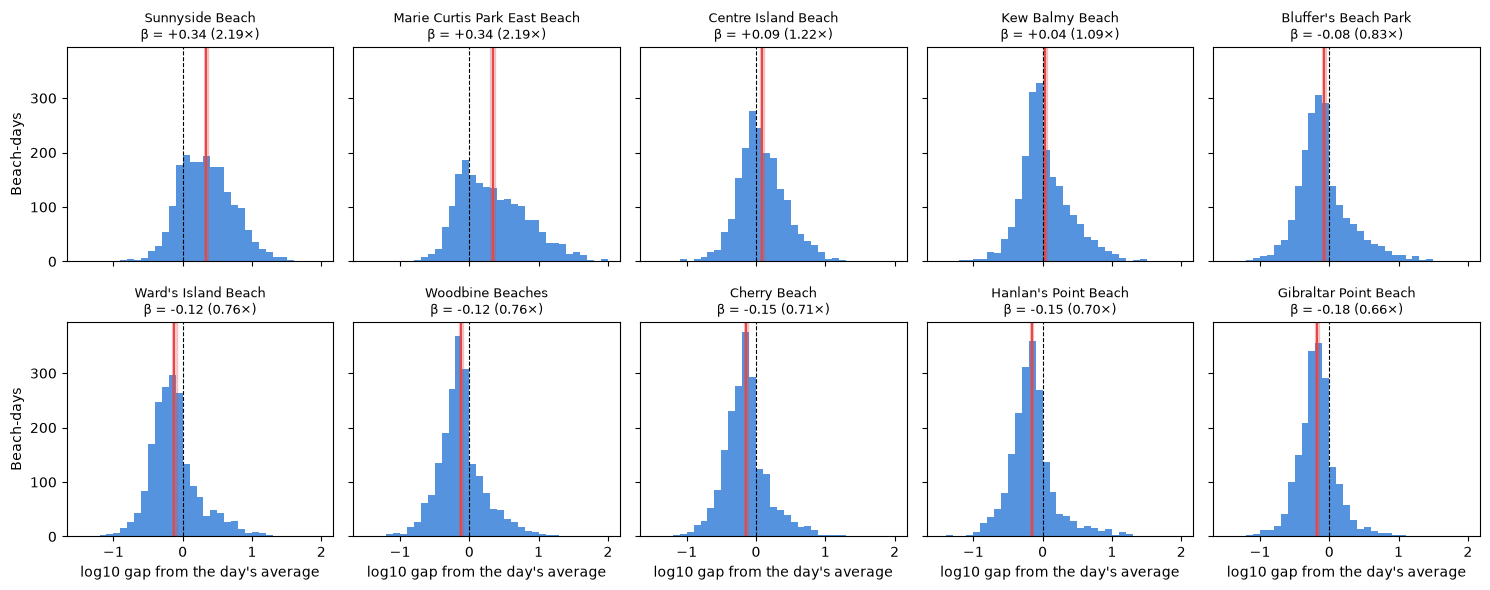

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)
for axis, row in zip(axes.flat, table.iter_rows(named=True)):
    values = relative.filter(pl.col("beach") == row["beach"])["relativeToDay"].to_numpy()
    axis.hist(values, bins=np.arange(-1.5, 2.01, 0.1), color="#2a78d6", alpha=0.8)
    axis.axvspan(row["low95"], row["high95"], color="#e34948", alpha=0.25)
    axis.axvline(row["beta"], color="#e34948", linewidth=1.5)
    axis.axvline(0, color="black", linewidth=0.8, linestyle="--")
    name = relative.filter(pl.col("beach") == row["beach"])["beachName"][0]
    axis.set_title(f"{name}\nβ = {row['beta']:+.2f} ({row['timesAverageBeach']:.2f}×)", fontsize=9)
for axis in axes[1]:
    axis.set_xlabel("log10 gap from the day's average")
for axis in axes[:, 0]:
    axis.set_ylabel("Beach-days")
fig.tight_layout()
plt.show()

## The same thing over time, for two beaches

Every beach-day for the worst and the cleanest beach, against date. The horizontal lines are each beach's $\beta_b$. The fitted "model" is just these two flat lines; everything around them is $\varepsilon_{bd}$.

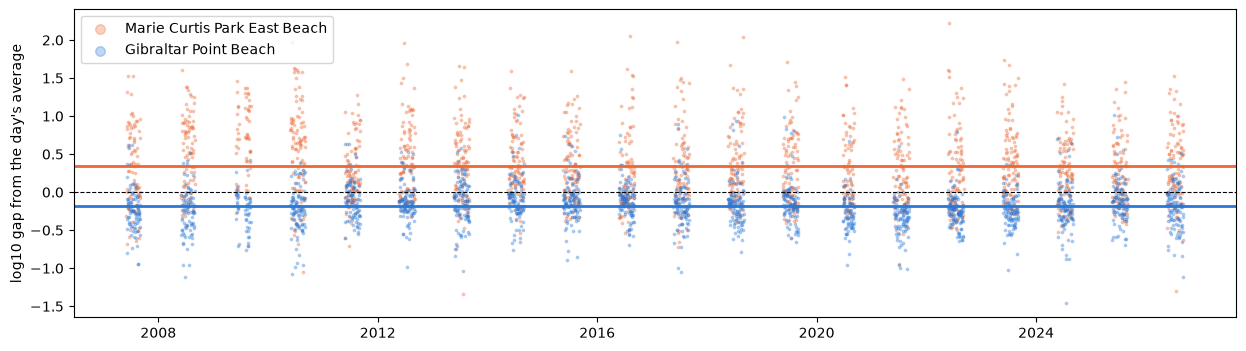

In [6]:
fig, axis = plt.subplots(figsize=(15, 4))
for beach_name, colour in [("Marie Curtis Park East Beach", "#eb6834"), ("Gibraltar Point Beach", "#2a78d6")]:
    beach_days = relative.filter(pl.col("beachName") == beach_name)
    axis.scatter(beach_days["collectionDate"], beach_days["relativeToDay"], s=3, alpha=0.3, color=colour, label=beach_name)
    beta = beach_days["relativeToDay"].mean()
    axis.axhline(beta, color=colour, linewidth=2)
axis.axhline(0, color="black", linewidth=0.8, linestyle="--")
axis.set_ylabel("log10 gap from the day's average")
axis.legend(loc="upper left", markerscale=4)
plt.show()